In [1]:
import sys
sys.path.append('../lib')
import numpy as np
import pymaster as nmt
import matplotlib.pyplot as plt
import analys_lib as an

In [2]:
# Inputs

nside = 64
lmax = 2*nside-1
fsky = 0.7
scale = 10
Nlbin = 10
dusttype = 'b'
synctype = 'b'
Pathload = '/pscratch/sd/s/svinzl/B_modes_project/'
N = 250
cov_type = 'Nmt-fg'
kw = ''
kws = ''
dusttype_cov = dusttype
synctype_cov = synctype
gaussbeam = True
bandpass = True
Ngrid = 50
cmb_e2e = True
n_iter = 3
adaptative = False
pl_moms = False
HVTWD = False
global_r = False
gnilc = False
kwv = '_v1' # should be '' or '_v1'
betabar = 1.48
tempbar = 19.6
betasbar = -3.1
nu0d = 402
nu0s = 40
FM_only = False
HM_only = False

if gaussbeam:
    kws += '_gaussbeam'
if bandpass:
    kws += '_bandpass'
if FM_only:
    kws += '_FM'
if HM_only:
    kws += '_HM'

if adaptative:
    kw += '_adaptative'

# Instrument

instr_name = 'litebird_full'
instr = np.load('../lib/instr_dict/%s.npy'%instr_name, allow_pickle=True).item()
freq = instr['frequencies']
if HM_only:
    freq = np.tile(freq, 2)
N_freqs = len(freq)
Ncross = int(N_freqs * (N_freqs+1)/2)

if bandpass:
    bw = instr['bandwidths']
    if HM_only:
        bw = np.tile(bw, 2)
    freq_grids = np.zeros((N_freqs, Ngrid))
    for i in range(N_freqs):
        freq_grids[i] = np.geomspace(freq[i]-bw[i]/2, freq[i]+bw[i]/2, Ngrid)
    freq = freq_grids

freq_pairs = np.array([(i, j) for i in range(N_freqs) for j in range(i, N_freqs)])
nu_i = freq[freq_pairs[:, 0]]
nu_j = freq[freq_pairs[:, 1]]

# Binning scheme

b = nmt.NmtBin.from_lmax_linear(lmax=lmax, nlb=Nlbin, is_Dell=True)
leff = b.get_effective_ells()
Nbins = len(leff)

In [17]:
# Initialize the fits

data = np.load(Pathload+'/power_spectra/DLcross_nside%s_fsky%s_scale%s_Nlbin%s_d%ss%sc' % (nside, fsky, scale, Nlbin, dusttype, synctype)+kws+'.npy')[:, :, :Nbins]
covmat = np.load(Pathload+'covariances/cov_%s_nside%s_fsky%s_scale%s_Nlbin%s_d%ss%sc' % (cov_type, nside, fsky, scale, Nlbin, dusttype_cov, synctype_cov)+kws+'.npy')[:Ncross*Nbins, :Ncross*Nbins]
results = np.load('../best_fits/results_d%ss%s_%s_scale%s_Nlbin%s_%s%s_ds_o1bts_analytical.npy' % (dusttype, synctype, fsky, scale, Nlbin, cov_type, kws), allow_pickle=True).item()

betabar = np.mean(results['beta_d'])
tempbar = np.mean(results['T_d'])
betasbar = np.mean(results['beta_s'])

comp = [['A', 'As', 'Asd', 'Aw1b', 'Aw1t', 'w1bw1b', 'w1tw1t', 'w1bw1t', 'Asw1bs', 'w1bsw1bs', 'Asw1b', 'Asw1t', 'Aw1bs', 'w1bw1bs', 'w1tw1bs']
           for i in range(1)]

gauss = an.gauss_like(freq, np.array([leff[-1]]), covmat[(Nbins-1)*Ncross:Ncross*Nbins, (Nbins-1)*Ncross:Ncross*Nbins], comp, betabar, tempbar, betasbar, nu0d, nu0s)

In [18]:
# Run PCA

F = gauss.A.T @ gauss.N_inv @ gauss.A

eigenvals, eigenvects = np.linalg.eigh(F)

In [19]:
sort = np.argsort(eigenvals)[::-1]
eigenvals_sorted = eigenvals[sort]
eigenvects_sorted = eigenvects[:, sort]

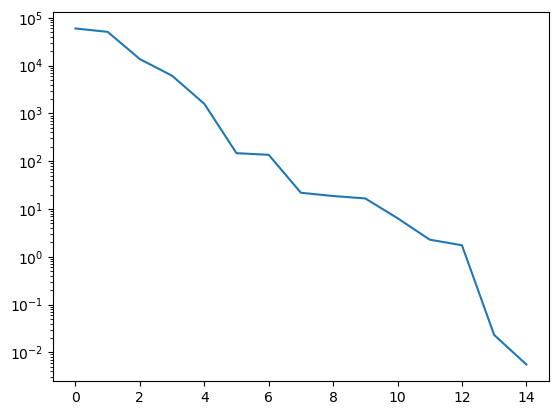

In [20]:
plt.figure(figsize=(6.4, 4.8))
plt.plot(eigenvals_sorted)
plt.yscale('log')
plt.show()

In [21]:
for i in range(len(comp[0])):
    print(f'comp {i}: lambda = {eigenvals_sorted[i]}')
    for j in range(len(comp[0])):
        print(f'{eigenvects_sorted[j,i]} {comp[0][j]}')
    print('\n')

comp 0: lambda = 59563.88907299174
-2.2951641012205478e-05 A
-0.033118044157493184 As
0.0008522289927366837 Asd
4.2799329413432995e-05 Aw1b
-0.0005601069508016955 Aw1t
0.0019306117451288313 w1bw1b
0.03381604913795401 w1tw1t
-0.02193437434244367 w1bw1t
0.019674103482474968 Asw1bs
0.013883921508886336 w1bsw1bs
-0.09572726109785497 Asw1b
0.921389198411203 Asw1t
0.0003402019853115495 Aw1bs
-0.03929190633218173 w1bw1bs
0.3701732254346818 w1tw1bs


comp 1: lambda = 50595.20189038026
0.0002677934003351561 A
-0.0028872204257380796 As
-0.0005652478387406373 Asd
-0.0005718926723720236 Aw1b
0.0056713591767081906 Aw1t
0.012537345250020109 w1bw1b
0.9587386847983372 w1tw1t
-0.22125321901356532 w1bw1t
-0.013167510786600695 Asw1bs
0.00023388862061625437 w1bsw1bs
0.011638392823212561 Asw1b
-0.0985387337030394 Asw1t
-8.062933119269938e-05 Aw1bs
-0.01493413261850086 w1bw1bs
0.14637942681728203 w1tw1bs


comp 2: lambda = 13629.013683187122
0.00027743403319946094 A
-0.7419892813352906 As
-0.001177241533774

In [166]:
def correlation_from_covariance(covariance):
    v = np.sqrt(np.diag(covariance))
    outer_v = np.outer(v, v)
    correlation = covariance / outer_v
    correlation[covariance == 0] = 0
    return correlation

cor_F = correlation_from_covariance(F)

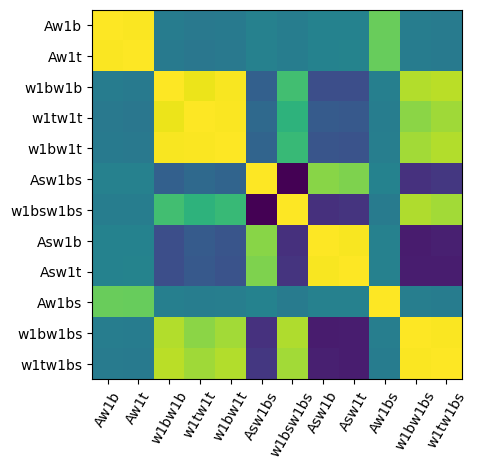

In [167]:
plt.figure(figsize=(6.4, 4.8))
plt.imshow(cor_F)
plt.xticks(np.arange(len(comp[0])), labels=comp[0], rotation=60)
plt.yticks(np.arange(len(comp[0])), labels=comp[0])
plt.show()